# E12: PerturbOT monocyte sublabel accuracy

**Started:** February 16, 2026

**Last updated:** February 23, 2026

**Research questions:** Does Perturb-OT have better subclass accuracy compared to OTDD and base entropic GW?

**Hypothesis:** Perturb-OT will get subclass matching accuracy above 90%+ for couplings between individuals, 80% between humans, and 50% between species, all higher than OTDD and base entropic GW.

**Conclusion:** 100% within-donor monocyte subtype accuracy on first try with 200 cells. But with 500, doesn't work well (~60% match). Monocytes are closest to a cell of the same subtype ~55-85% of the time, suggesting there may be better ways to form nearest neighbor graphs (maybe subset of genes).

**Potential Next Steps:** Investigate how Pinar Demetci found that geodesic graph distances are better than Euclidean distances. Investigate which genes drive clustering the most (which HVGs have highest R^2 between pairs).

In [2]:
from __future__ import annotations
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy as sp
from scipy.spatial.distance import cdist
from scipy import sparse
import ot
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import seaborn as sns
import random
from __future__ import annotations
from typing import Any, Dict, Hashable, Iterable, List, Sequence, Tuple, Union, Optional
from speciesot_helpers import label_uniform_cell_type_row, \
                              top_n_organisms_from_species, \
                              cell_types_with_n_per_organism, \
                              sample_equal_cell_types, \
                              ot_between_organisms, \
                              calc_random_mean_std, \
                              test_train_split_adata, \
                              get_cell_type_from_index, \
                              create_label_to_sample_dicts, \
                              concat_index, \
                              show_cell_type_results, \
                              cell_type_knn_acc, \
                              split_adata_by_celltype_tissue, \
                              match_cells_by_celltype_tissue, \
                              combine_transport_plans, \
                              convert_ensembl_to_gene_symbols, \
                              nearest_neighbor_cell_type, \
                              nn_gene_r2
from speciesot_simulation_helpers import run_ot, \
                                         compute_mapping_acc, \
                                         sublabel_match_rate_from_gw, \
                                         plot_got_best_matches_with_labels, \
                                         gw_seeded, \
                                         plot_first_two_dims
import torch
from torch.utils.data import TensorDataset, DataLoader
from otdd.pytorch.datasets import load_torchvision_data
from otdd.pytorch.distance import DatasetDistance, IncomparableDatasetDistance
from pytorch_helpers import fit_mlp
import perturbot
from perturbot.match import get_coupling_egw_labels_ott
#from perturbot.predict import train_mlp
%matplotlib inline

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
ot.gpu not found - coupling computation will be in cpu


### Data setup

In [3]:
human_dir = 'data/tabula_sapiens/'
mouse_dir = 'data/tabula_muris/'

In [4]:
human_adatas = top_n_organisms_from_species(human_dir, 2, 'human')

In [5]:
human1_adata = human_adatas[0]
convert_ensembl_to_gene_symbols(human1_adata, species="human", make_unique=True)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesot_helpers.py:839: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["ensembl_id"] = orig_ids


In [6]:
human1a, human1b = split_adata_by_celltype_tissue(human1_adata, cell_number=2000, min_per_cell_type=5)

In [7]:
human1a = human1a[human1a.obs['cell_type']!='monocyte']  # remove generic 'monocyte' cell type
human1b = human1b[human1b.obs['cell_type']!='monocyte']

In [8]:
num_cells = human1a.obsm['X_pca'].shape[0]

In [9]:
sc.tl.pca(human1a, n_comps=50, svd_solver="arpack")
sc.tl.pca(human1b, n_comps=50, svd_solver="arpack")

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:383: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


In [10]:
human1a.obs['shared_cell_type'].value_counts()

shared_cell_type
T cell                     390
endothelial cell           248
pulmonary alveolar cell    224
fibroblast                 204
thymocyte                  135
HPSC                       132
macrophage                 112
goblet cell                101
neutrophil                  86
monocyte                    74
smooth muscle cell          46
mesenchymal stem cell       45
plasma cell                 44
erythrocyte                 30
NK cell                     29
pericyte                    25
B cell                      16
basophil                    12
dendritic cell              11
mast cell                   11
bladder urothelial cell     10
Schwann cell                 2
myocyte                      2
Name: count, dtype: int64

In [11]:
ct_vc = human1a.obs['shared_cell_type'].value_counts()
ct_keep = ct_vc[ct_vc>=2].index.tolist()

In [12]:
human1a = human1a[human1a.obs['shared_cell_type'].isin(ct_keep)]
human1b = human1b[human1b.obs['shared_cell_type'].isin(ct_keep)]

### Initial PerturbOT run

In [44]:
human1a_X = human1a.obsm['X_pca']
human1b_X = human1b.obsm['X_pca']
human1a_labels = human1a.obs['shared_cell_type'].tolist()
human1b_labels = human1b.obs['shared_cell_type'].tolist()

In [45]:
X_dict, Y_dict, X_full_dict, Y_full_dict, X_index_dict, Y_index_dict = create_label_to_sample_dicts(human1a, 
                                                                                                    human1b)

In [46]:
T_dict, log = get_coupling_egw_labels_ott((X_dict, Y_dict), 1e-4)

running EGWL with ott
GW called
lse step
updating linearization
Label considered for Sinkhorn run
lse step
updating linearization
Label considered for Sinkhorn run
5 outer iterations were needed.
The last Sinkhorn iteration has converged: False
The outer loop of Gromov Wasserstein has converged: False
The final regularized GW cost is: 6.610
Done running LEGWOT with ott


In [47]:
T_full, human1a_ct, human1a_cst, human1b_ct, human1b_cst= combine_transport_plans(T_dict, 
                                                                                  X_index_dict,
                                                                                  Y_index_dict,
                                                                                  human1a,
                                                                                  human1b)

In [48]:
T_full

array([[1.06561174e-06, 5.21636609e-23, 6.18422291e-08, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.82874797e-26, 4.84100410e-20, 3.43636702e-10, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.08604796e-15, 3.62532404e-08, 1.83616976e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        5.36858970e-05, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 3.11899028e-04, 1.90859442e-04],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.90859442e-04, 3.11899028e-04]],
      shape=(1989, 1989))

In [49]:
compute_mapping_acc(T_full, human1a_ct, human1b_ct)

1.0

In [50]:
human1a[human1a.obs['shared_cell_type']=='monocyte'].obs['cell_type'].value_counts()

cell_type
classical monocyte        38
intermediate monocyte     28
non-classical monocyte     8
Name: count, dtype: int64

In [51]:
monocyte_cst1a = []
for cst in human1a_cst:
    if cst == 'classical monocyte':
        cst_val = 1
    elif cst == 'intermediate monocyte':
        cst_val = 2
    elif cst == 'non-classical monocyte':
        cst_val = 3
    else:
        cst_val = 0
    monocyte_cst1a.append(cst_val)

In [52]:
monocyte_cst1b = []
for cst in human1b_cst:
    if cst == 'classical monocyte':
        cst_val = 1
    elif cst == 'intermediate monocyte':
        cst_val = 2
    elif cst == 'non-classical monocyte':
        cst_val = 3
    else:
        cst_val = 0
    monocyte_cst1b.append(cst_val)

In [53]:
sublabel_match_rate_from_gw(T_full, human1a_ct, human1b_ct, monocyte_cst1a, monocyte_cst1b)

0.5675675675675675

### Investigating monocyte markers

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


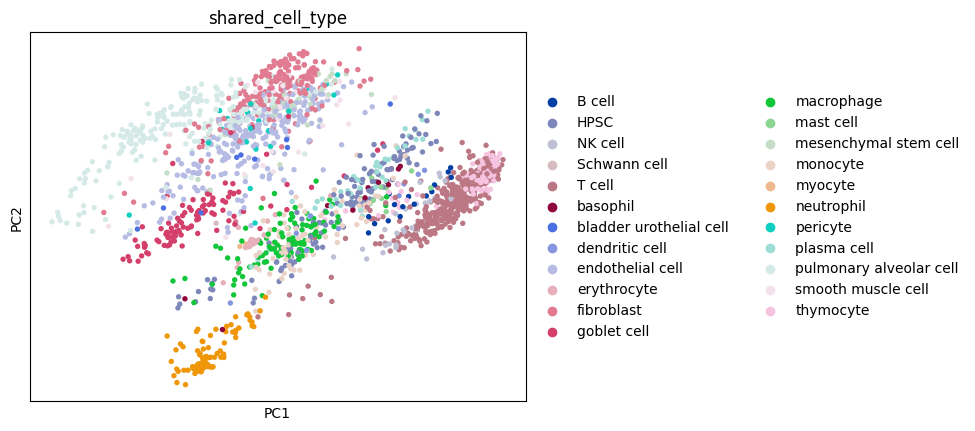

In [15]:
sc.pl.pca(human1a, color=['shared_cell_type'])

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


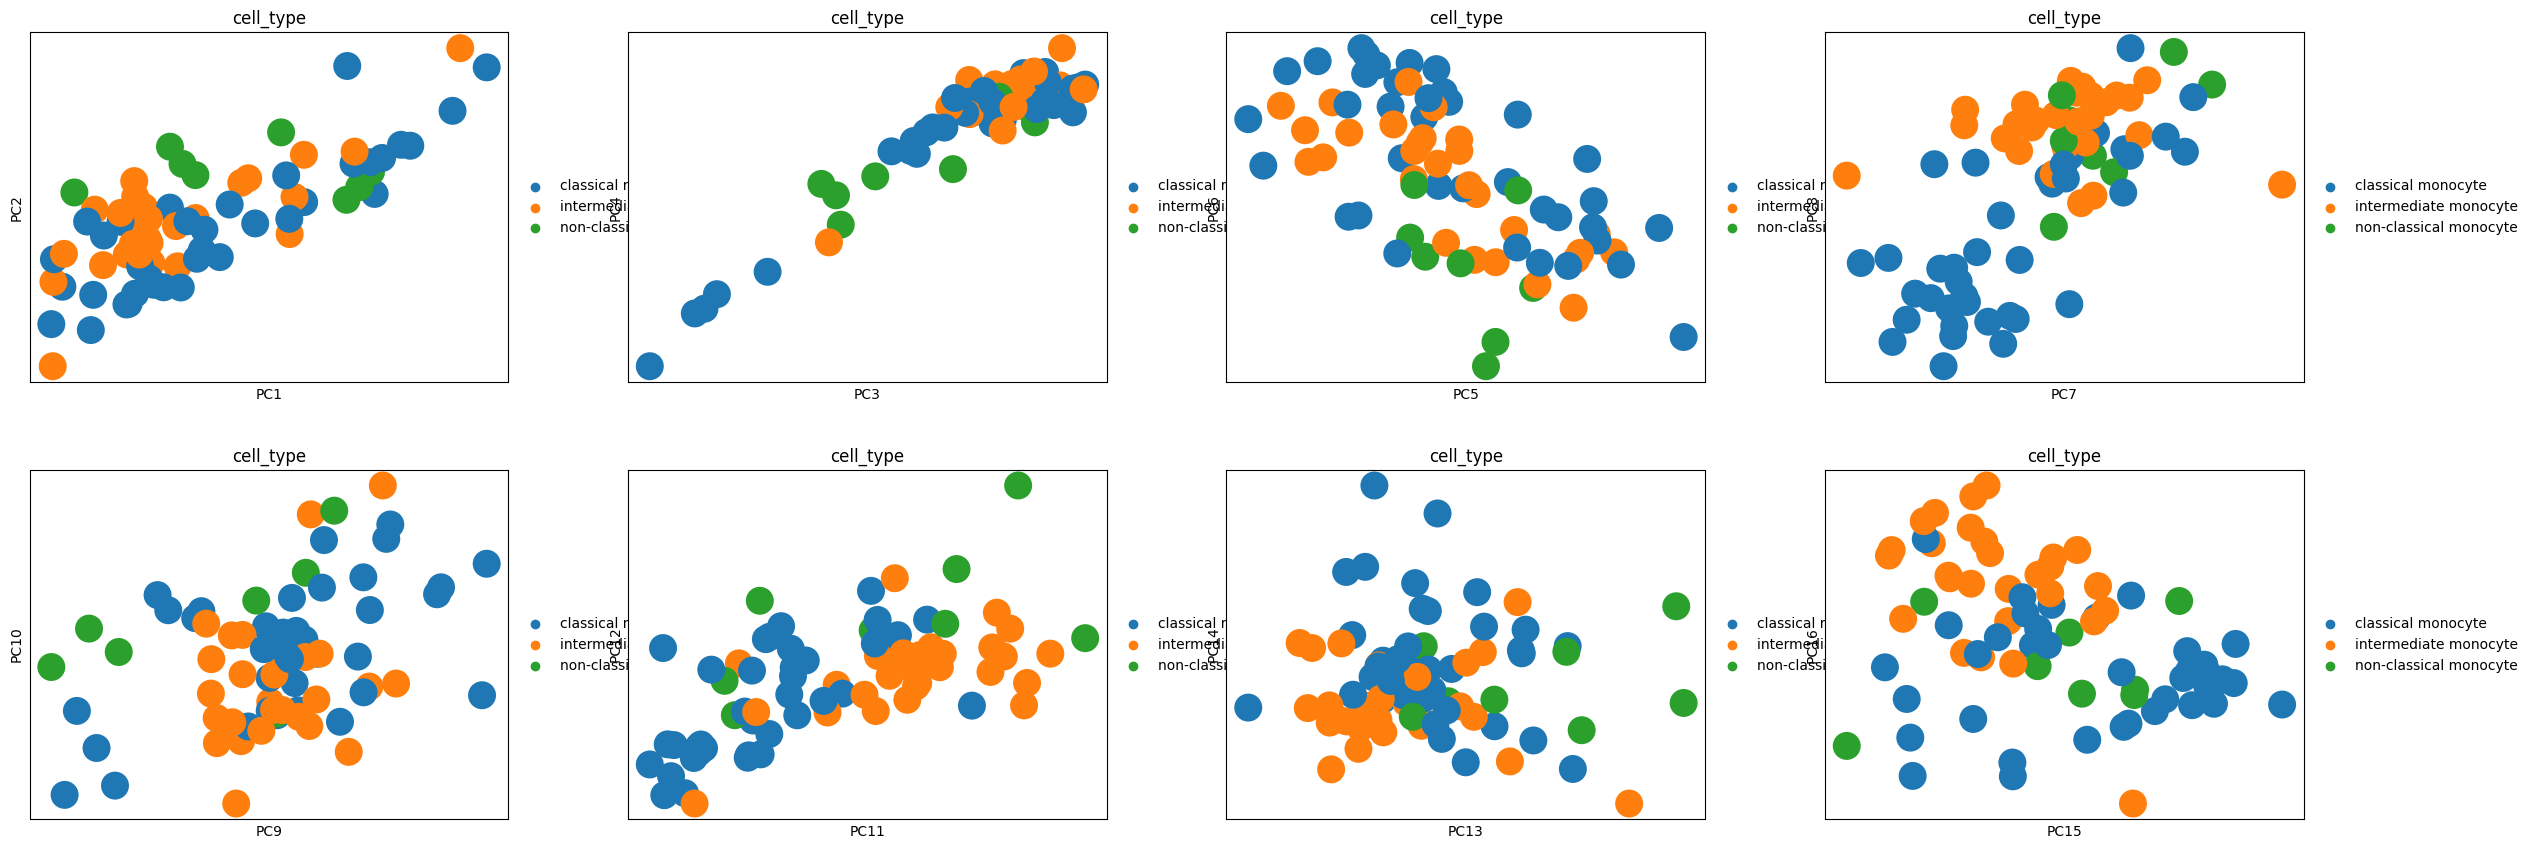

In [16]:
sc.pl.pca(human1a[human1a.obs['shared_cell_type']=='monocyte'], color=['cell_type'], 
          dimensions=[(0,1),(2,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15)])

In [81]:
monocytes1a= human1a[human1a.obs['shared_cell_type']=='monocyte']

In [82]:
convert_ensembl_to_gene_symbols(monocytes1a, species="human", make_unique=True)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesot_helpers.py:839: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["ensembl_id"] = orig_ids


In [83]:
sc.pp.normalize_total(monocytes1a, target_sum=1e4)  # library size normalize (not TPM exactly, but similar idea)
sc.pp.log1p(monocytes1a)
monocytes1a.raw = monocytes1a.copy()
sc.pp.highly_variable_genes(monocytes1a)
sc.pp.scale(monocytes1a)  # zero mean, unit variance per gene

/n/sw/Miniforge3-24.7.1-0/lib/python3.12/functools.py:907: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [84]:
monocytes1a

AnnData object with n_obs × n_vars = 74 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'develo

In [20]:
sc.tl.pca(monocytes1a, n_comps=50, svd_solver="arpack")

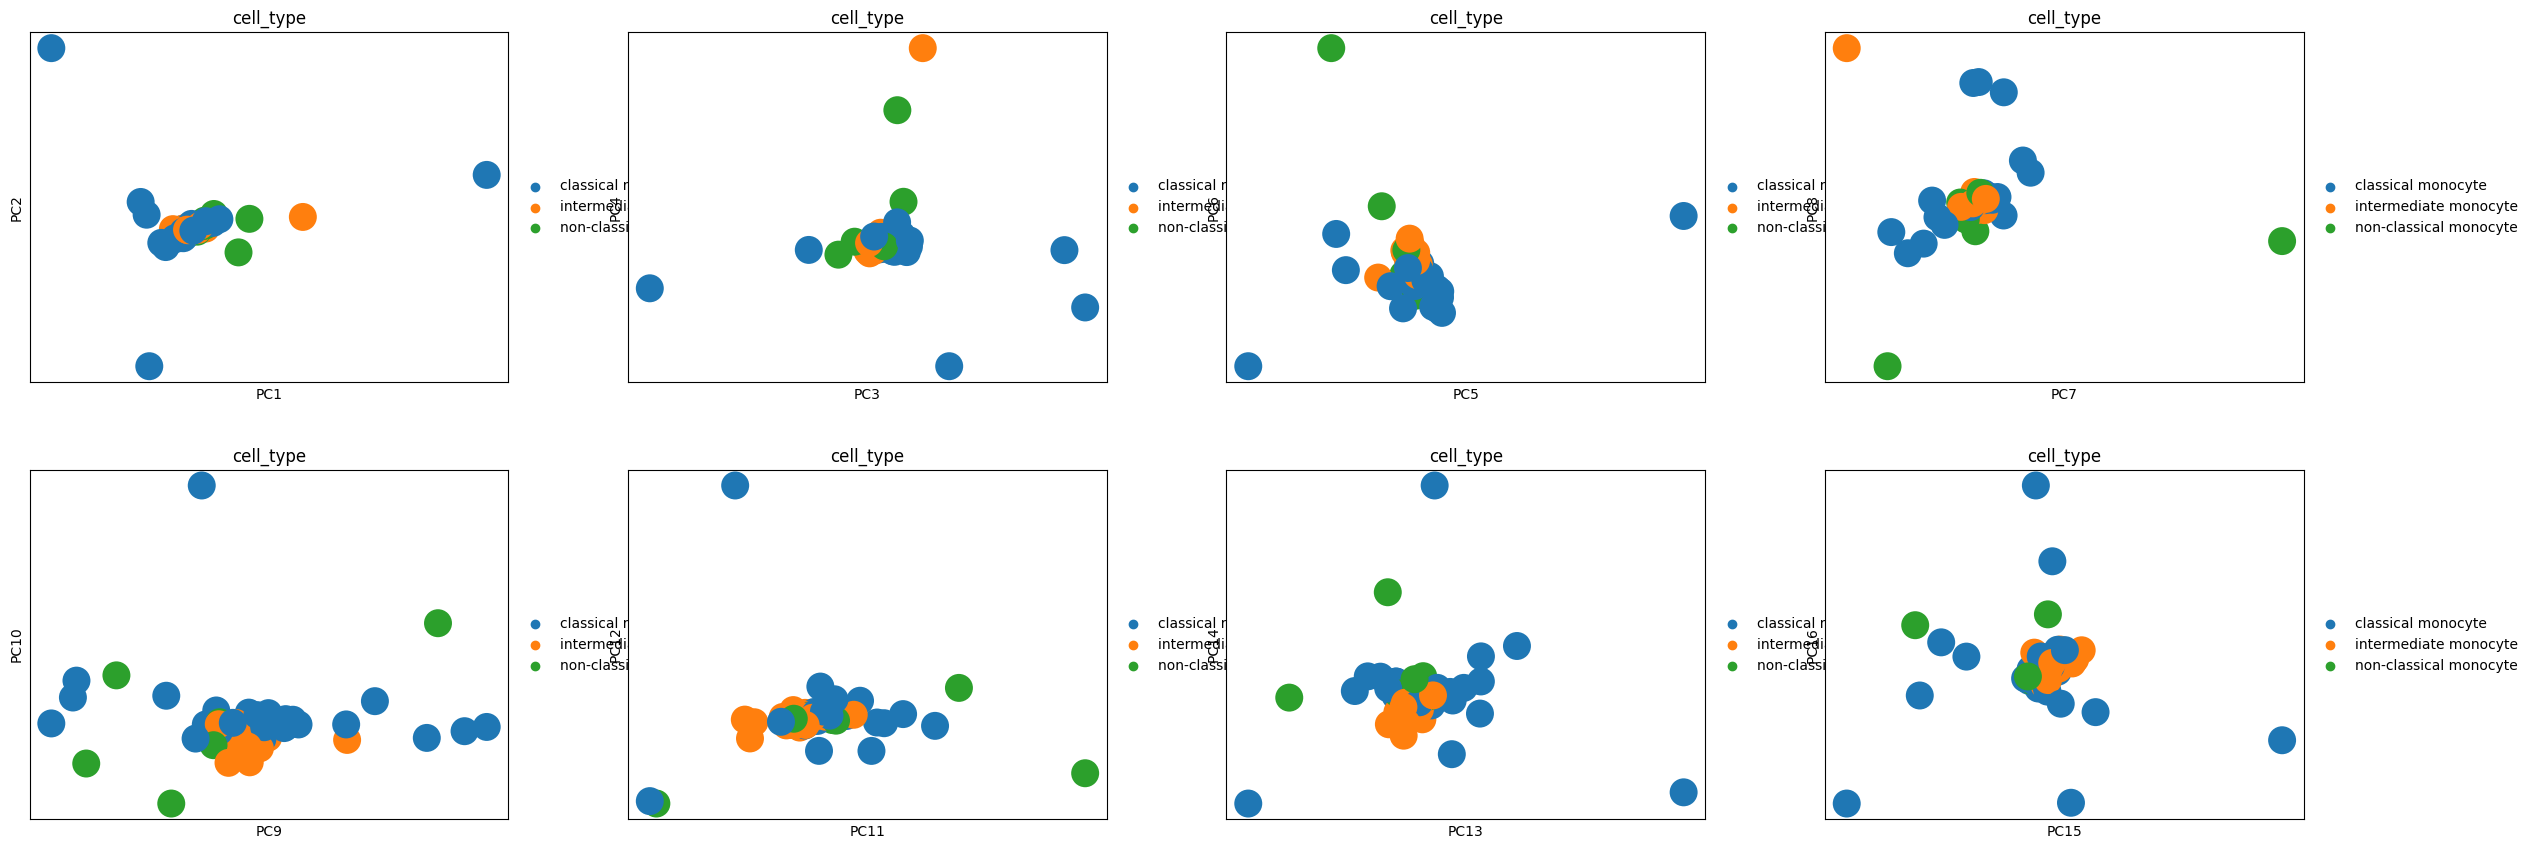

In [21]:
sc.pl.pca(monocytes1a, color=['cell_type'], 
          dimensions=[(0,1),(2,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15)])

In [22]:
sc.pp.neighbors(monocytes1a)
sc.tl.umap(monocytes1a, n_components=16)

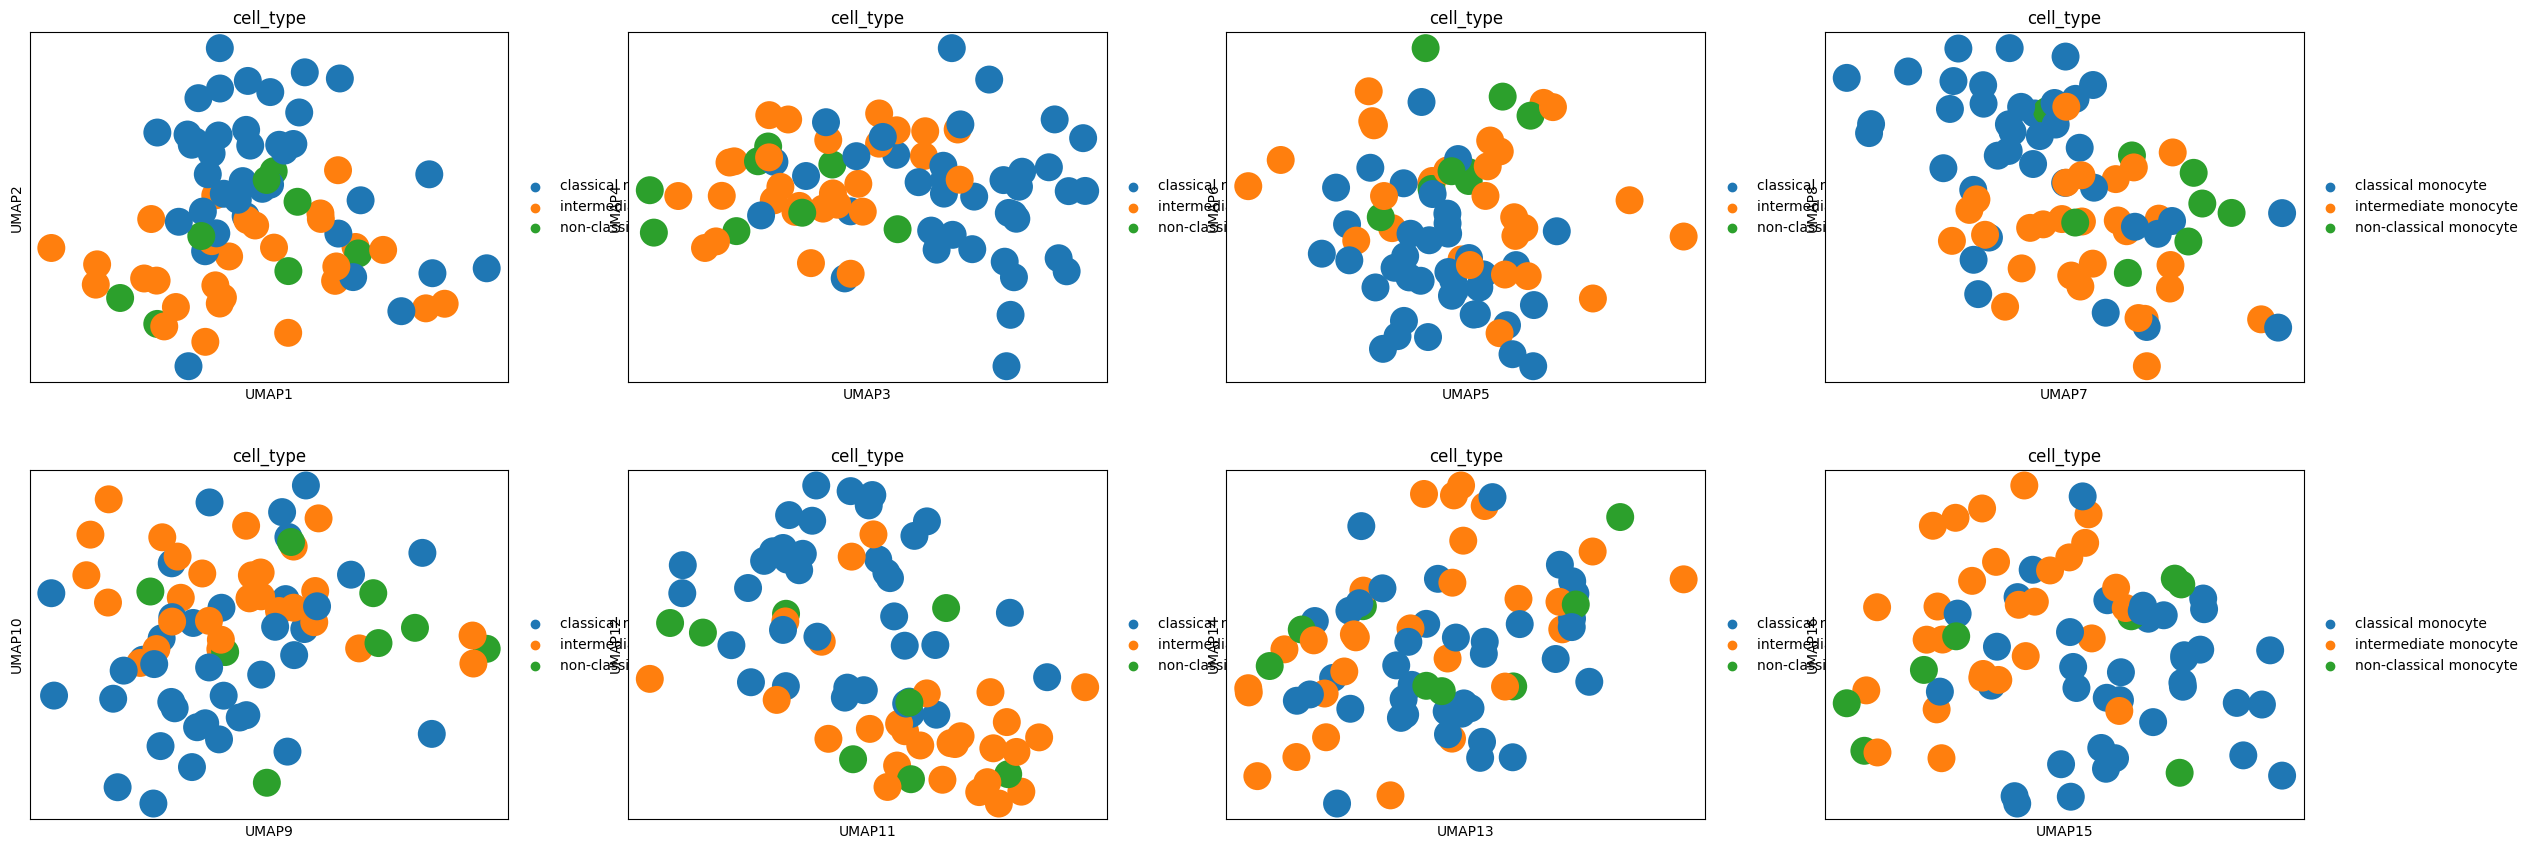

In [23]:
sc.pl.umap(monocytes1a, color=['cell_type'], dimensions=[(0,1),(2,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15)])

In [24]:
monocytes1a.var_names

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'FIRRM', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'ENSG00000290126', 'ENSG00000290127', 'ENSG00000290146',
       'GUCA1ANB-GUCA1A', 'ENSG00000290149', 'ENSG00000290162',
       'ENSG00000290163', 'ENSG00000290164', 'ENSG00000290165',
       'ENSG00000290166'],
      dtype='object', length=61759)

### In nearest neighbor graphs, is nearest neighbor usually the same cell type?

In [27]:
nearest_neighbor_cell_type(monocytes1a)

TSP14_Spleen_NA_10X_2_1_TTCCACGGTTGGCCTG              intermediate monocyte
TSP14_Lung_Proximal_10X_1_1_CATGCAAAGGTGCATG             classical monocyte
TSP14_Blood_NA_10X_2_1_GCCAGGTAGAGCACTG                  classical monocyte
TSP14_Lung_Proximal_10X_1_1_CTTTCAACAATCCTTT          intermediate monocyte
TSP14_Blood_NA_10X_2_1_CAACAGTGTGGTTCTA                  classical monocyte
                                                              ...          
TSP14_Lung_Distal_10X_1_1_GATTTCTAGGCACAAC            intermediate monocyte
TSP14_LymphNode_NA_10X_2_1_5Prime_GACCTGGCACAGGCCT    intermediate monocyte
TSP14_Lung_Proximal_10X_1_1_AGGCTGCCAGCGATTT          intermediate monocyte
TSP14_Spleen_NA_10X_1_1_5Prime_ACTTGTTGTCAAAGAT          classical monocyte
TSP14_Spleen_NA_10X_2_1_5Prime_GATCAGTCAGTCCTTC       intermediate monocyte
Name: nn_cell_type, Length: 74, dtype: object

In [28]:
np.mean(monocytes1a.obs['cell_type']==nearest_neighbor_cell_type(monocytes1a))

np.float64(0.6486486486486487)

Only 65% of monocytes have a cell of the same subtype as their nearest neighbor. 

Is it because cycling cells are clustering?

In [29]:
'TOP2A' in monocytes1a.var_names

True

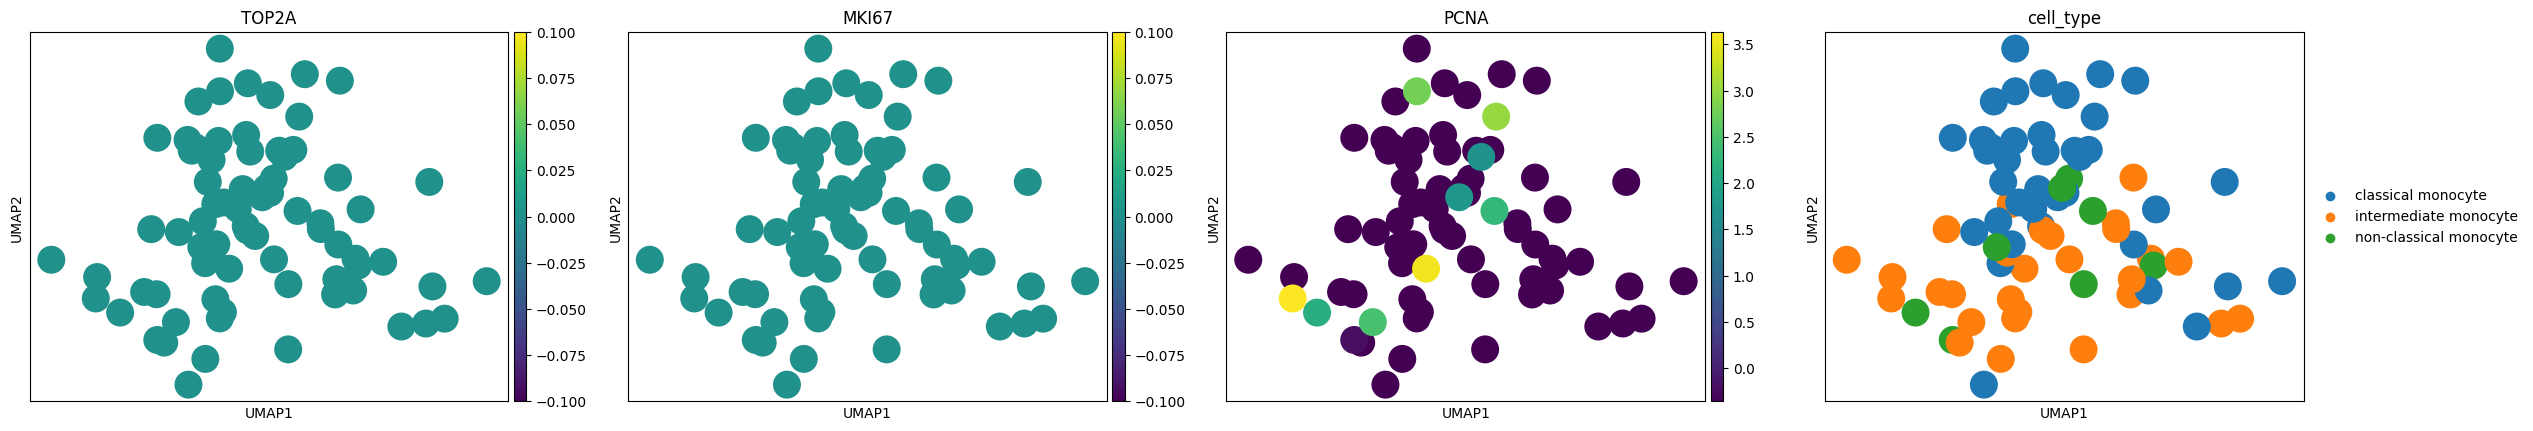

In [30]:
sc.pl.umap(monocytes1a, color=['TOP2A', 'MKI67', 'PCNA', 'cell_type'], use_raw=False)

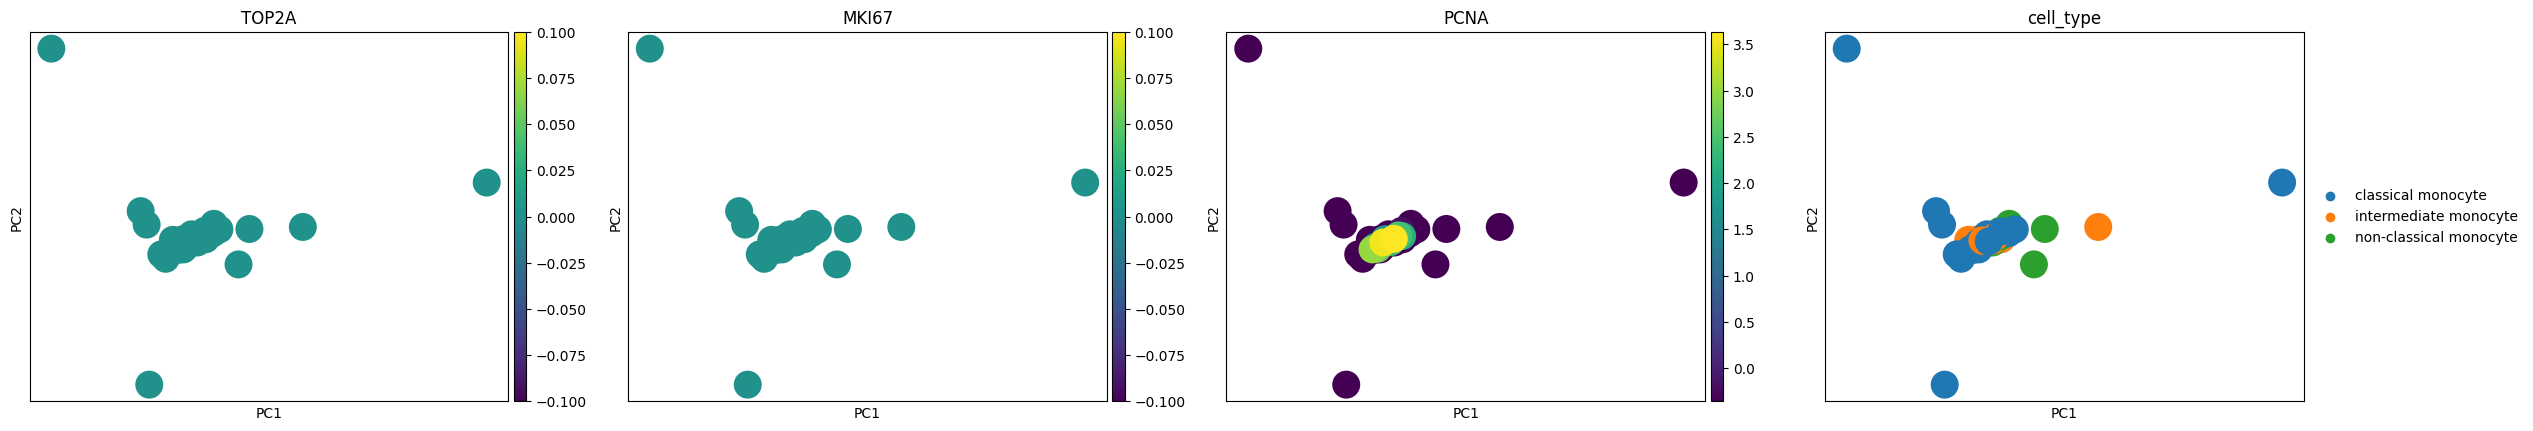

In [31]:
sc.pl.pca(monocytes1a, color=['TOP2A', 'MKI67', 'PCNA', 'cell_type'], use_raw=False)

In [32]:
# reduce to monocyte identity genes
monocyte_gene_list = ['CD14', 'FCGR3A', 'ITGAM', 'CCR2', 'CX3CR1', 'S100A8', 'S100A9', 'CLEC4D', 'CLEC10A', 'CRTH2', 'SIGLEC10', 'ACTG1', 'ATB']
monocyte_genes_present = [g for g in monocyte_gene_list if g in monocytes1a.var_names]
monocytes1a_identity = monocytes1a[:, monocyte_genes_present].copy()

In [35]:
X = monocytes1a_identity.X
print("X shape:", X.shape)

for k in ["X_pca", "X_umap"]:
    if k in monocytes1a_identity.obsm:
        print(k, monocytes1a_identity.obsm[k].shape)

X shape: (74, 11)
X_pca (74, 50)
X_umap (74, 16)


In [36]:
monocytes1a_identity.var.get("highly_variable", None).sum()

np.int64(2)

In [37]:
sc.tl.pca(monocytes1a_identity, n_comps=10, use_highly_variable=False,)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


In [38]:
monocytes1a_identity.var_names.tolist()

['CD14',
 'FCGR3A',
 'ITGAM',
 'CCR2',
 'CX3CR1',
 'S100A8',
 'S100A9',
 'CLEC4D',
 'CLEC10A',
 'SIGLEC10',
 'ACTG1']

In [39]:
mono1a_cd14 = np.array(monocytes1a_identity[:,'CD14'].X)

In [40]:
mono1a_cd16 = np.array(monocytes1a_identity[:,'FCGR3A'].X)

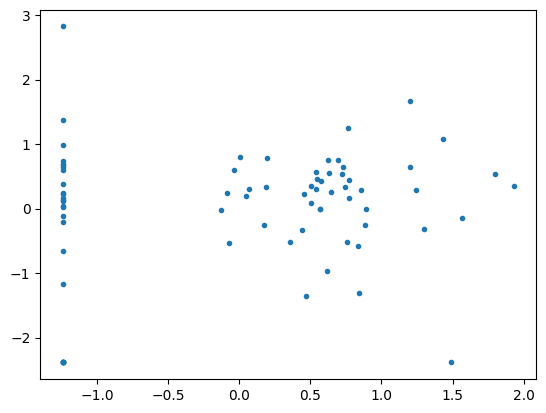

In [41]:
plt.plot(mono1a_cd16,mono1a_cd14,'.')

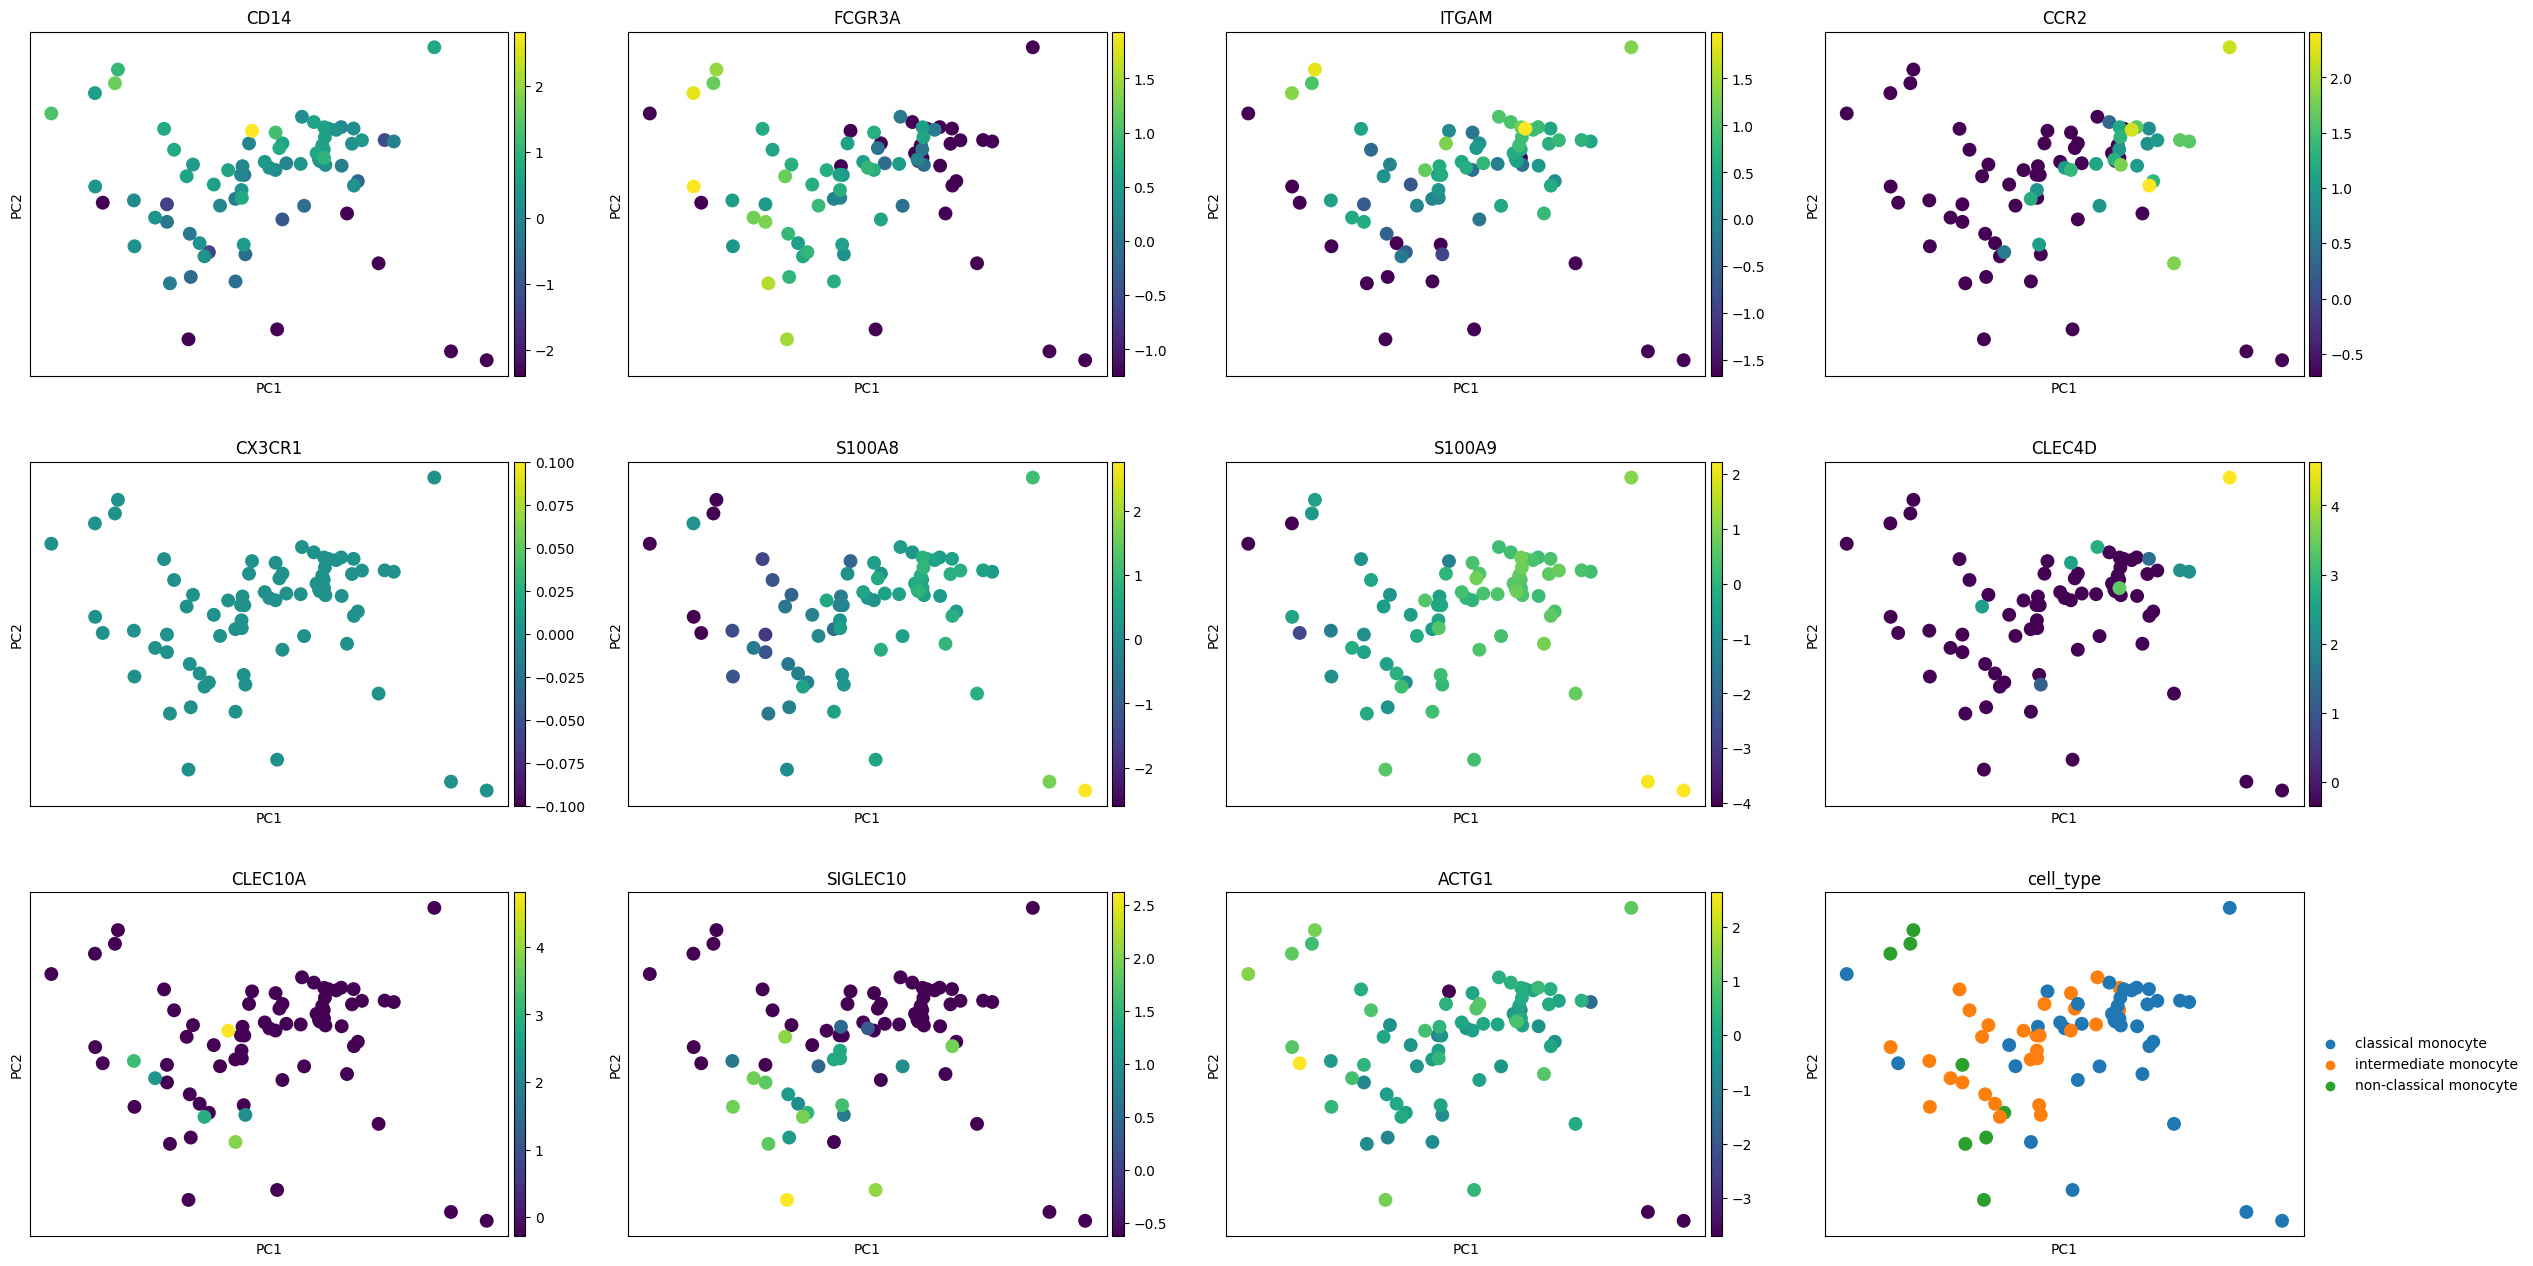

In [42]:
# classical markers: CD14++, FCGR3A-, ITGAM+, CSF1R+
#
sc.pl.pca(monocytes1a_identity, color=monocytes1a_identity.var_names.tolist()+['cell_type'], use_raw=False, s=400)

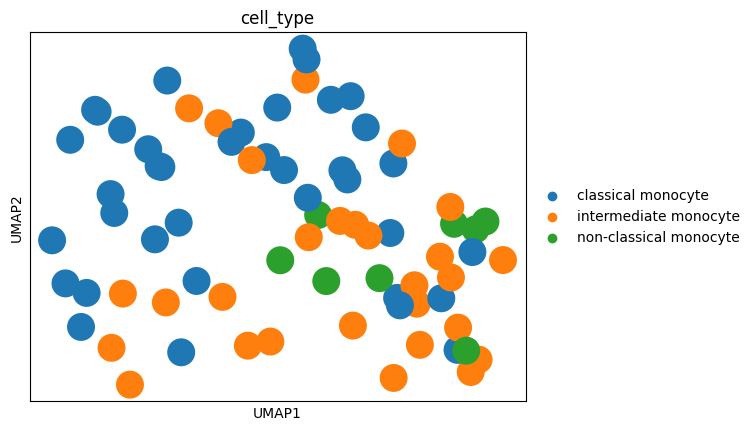

In [43]:
sc.pp.neighbors(monocytes1a_identity)
sc.tl.umap(monocytes1a_identity, n_components=5)
sc.pl.umap(monocytes1a_identity, color=['cell_type'])

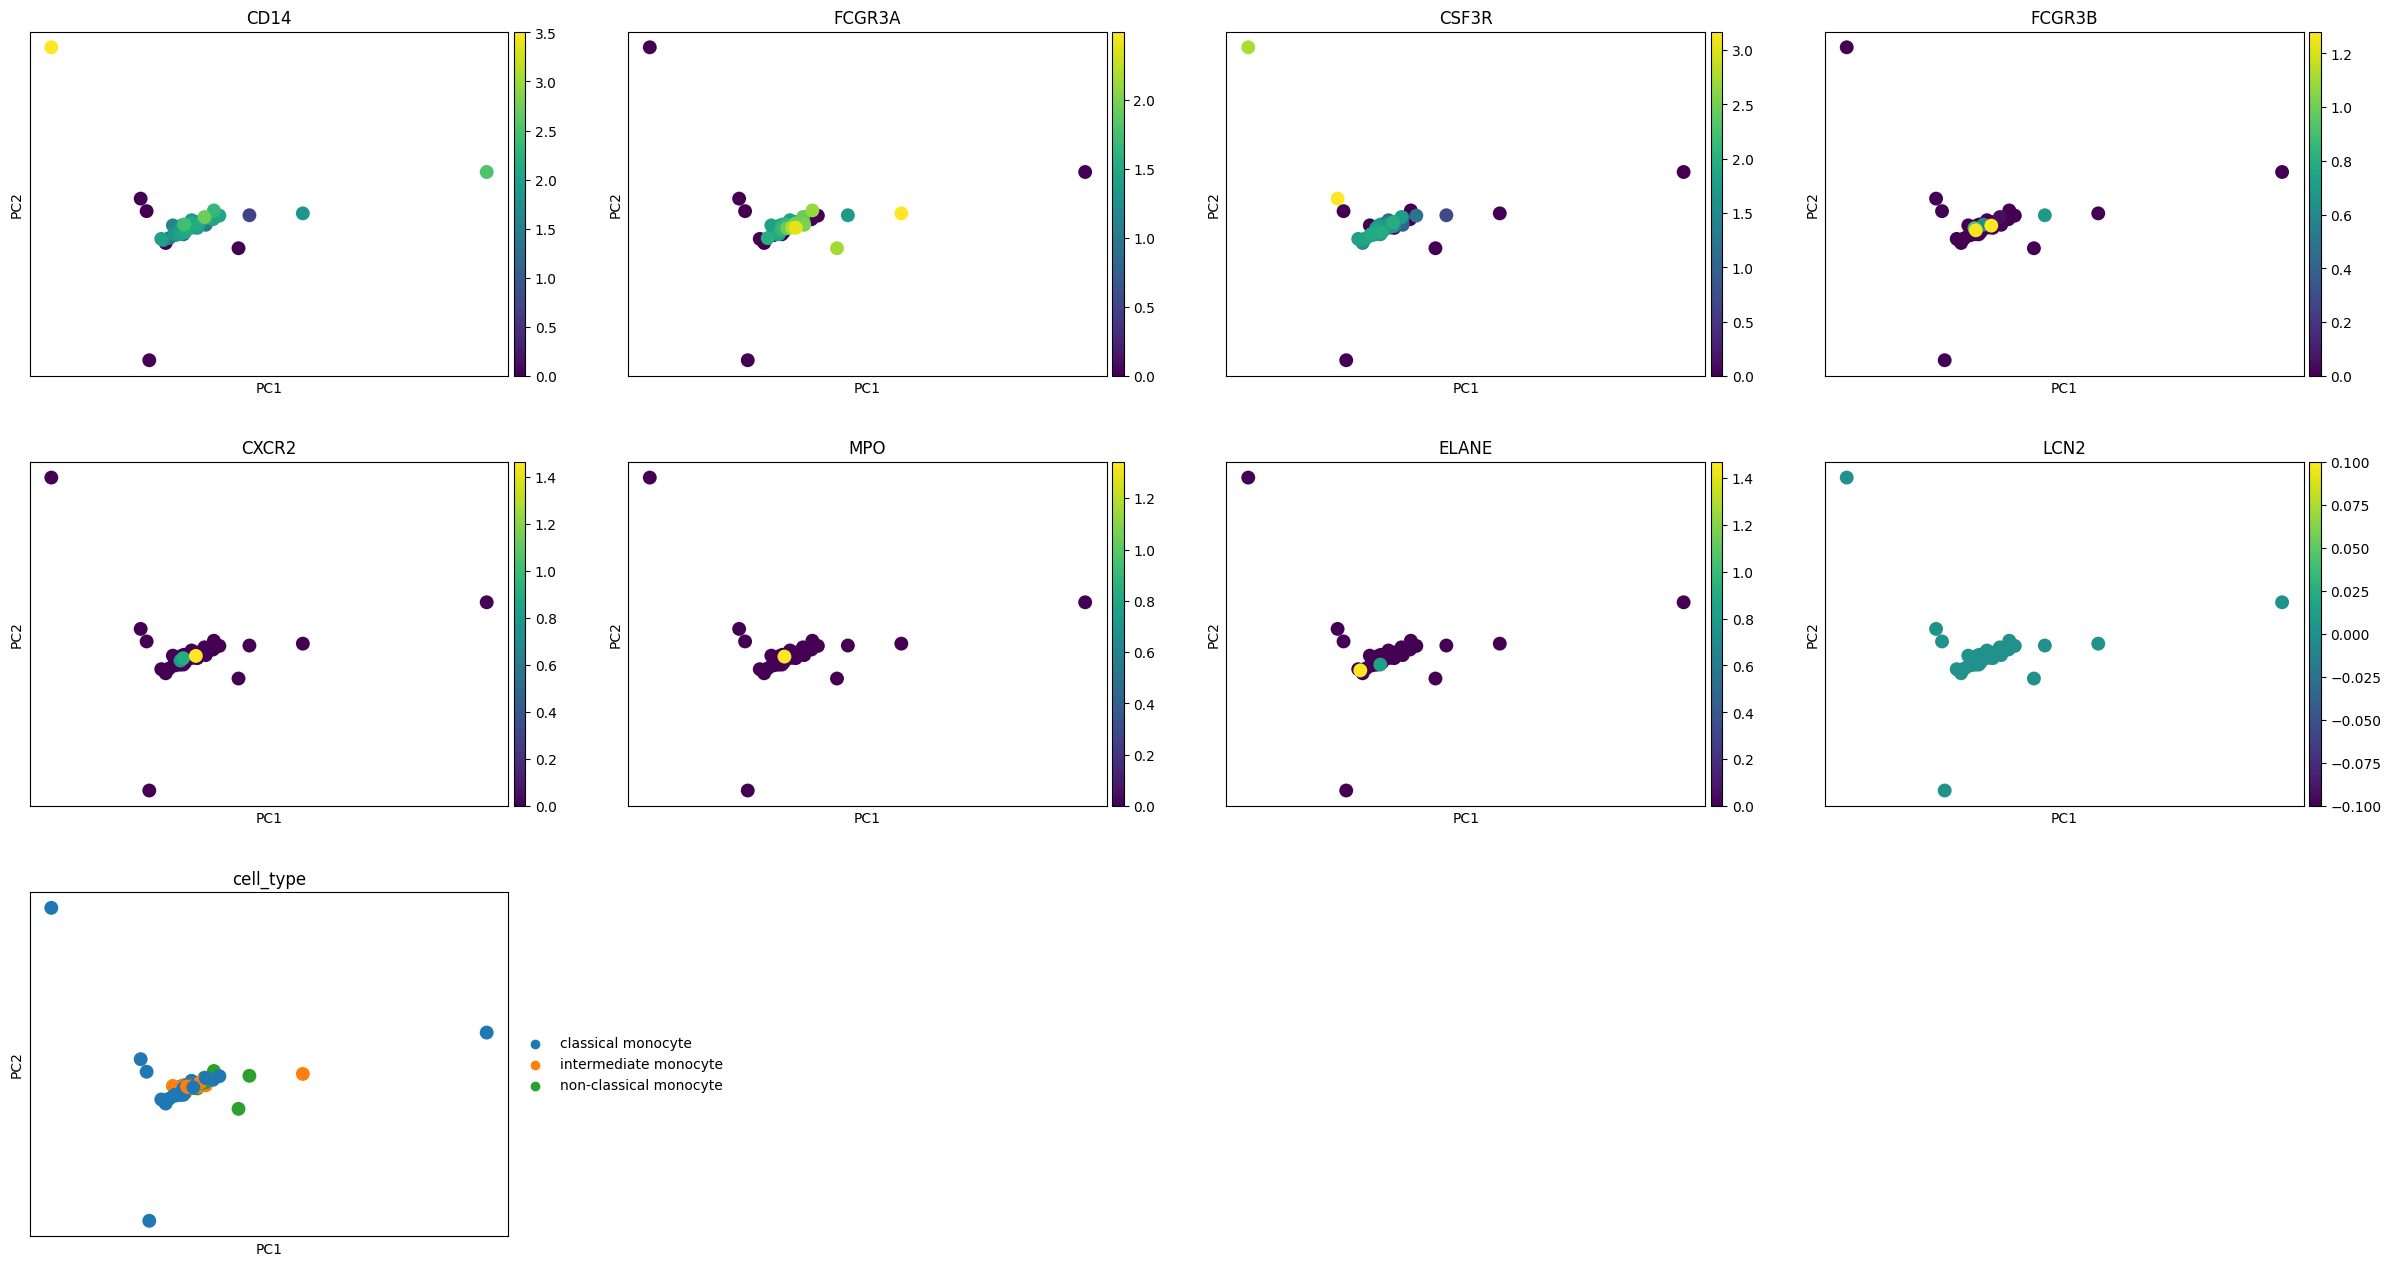

In [44]:
# check neutrophil markers: ['CSF3R', 'FCGR3B', 'CXCR2', 'MPO', 'ELANE', 'LCN2']
sc.pl.pca(monocytes1a, color=['CD14', 'FCGR3A', 'CSF3R', 'FCGR3B', 'CXCR2', 'MPO', 'ELANE', 'LCN2', 'cell_type'], s=400)

### R^2: optimal, subtype-restricted optimal, OT-paired, and random

In [46]:
def plot_gene_pair_expression_from_T(
    T_block,
    source_cell_ids,
    target_cell_ids,
    source_adata,
    target_adata,
    genes,
    *,
    use_raw=True,
    max_points=None,
):
    """
    For a single cell-type-specific transport plan T_block (n_src x n_tgt):
    - For each source cell i, pick best paired target j_hat[i] = argmax_j T_block[i, j]
    - For each gene, scatter:
        x = gene expression in source cell i
        y = gene expression in paired target cell j_hat[i]
      and annotate R^2 on the plot.
    """

    n_src = len(source_cell_ids)
    n_tgt = len(target_cell_ids)

    if T_block.shape != (n_src, n_tgt):
        raise ValueError(
            f"T_block shape {T_block.shape} must match "
            f"(len(source_cell_ids), len(target_cell_ids)) = ({n_src}, {n_tgt})."
        )

    # ---- argmax pairing ----
    if sparse.issparse(T_block):
        Tcsr = T_block.tocsr()
        j_hat = np.full(n_src, -1, dtype=int)
        for i in range(n_src):
            start, end = Tcsr.indptr[i], Tcsr.indptr[i + 1]
            cols = Tcsr.indices[start:end]
            vals = Tcsr.data[start:end]
            if cols.size:
                j_hat[i] = cols[np.argmax(vals)]
    else:
        j_hat = np.argmax(np.asarray(T_block), axis=1).astype(int)

    valid = j_hat >= 0
    src_ids = np.asarray(source_cell_ids, dtype=object)[valid]
    tgt_ids = np.asarray(target_cell_ids, dtype=object)
    j_hat = j_hat[valid]

    rng = np.random.default_rng(0)

    def _get_expr(adata, cell_ids, gene):
        A = (
            adata.raw
            if (use_raw and getattr(adata, "raw", None) is not None and gene in adata.raw.var_names)
            else adata
        )
        if gene not in A.var_names:
            return None
        X = A[cell_ids, gene].X
        if sparse.issparse(X):
            X = X.toarray()
        return np.asarray(X).reshape(-1)

    figs = []
    for gene in genes:
        x = _get_expr(source_adata, src_ids.tolist(), gene)
        if x is None:
            print(f"[skip] {gene}: not found in source")
            continue

        y_all = _get_expr(target_adata, tgt_ids.tolist(), gene)
        if y_all is None:
            print(f"[skip] {gene}: not found in target")
            continue

        y = y_all[j_hat]

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        if max_points is not None and x.size > max_points:
            idx = rng.choice(x.size, size=max_points, replace=False)
            x, y = x[idx], y[idx]

        if x.size >= 2 and np.var(y) > 0:
            a, b = np.polyfit(x, y, 1)
            y_pred = a * x + b
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
        else:
            r2 = np.nan

        fig, ax = plt.subplots()
        ax.scatter(x, y, s=10)
        ax.set_xlabel(f"Source {gene} expression")
        ax.set_ylabel(f"Argmax-paired target {gene} expression")
        ax.set_title(f"{gene}  (R²={r2:.3f})" if np.isfinite(r2) else f"{gene}  (R²=NA)")
        figs.append(fig)

    return figs


In [47]:
def plot_rank_matched_gene_expression(
    source_cell_ids,
    target_cell_ids,
    source_adata,
    target_adata,
    gene: str,
    *,
    use_raw: bool = True,
    max_points: int | None = None,
    label_restricted: str | None = None,
):
    """
    Rank-match cells by expression of `gene` and scatter x=source vs y=target for rank-aligned pairs.

    If `label_restricted` is not None:
      - interpret it as the obs column name (default: "label")
      - for each label value L present in BOTH adatas within the provided id lists:
          * take the cells with label==L in source and target
          * rank each subset by gene expression
          * pair by rank up to min(n_source_L, n_target_L)
      - concatenate pairs across labels
      - plot all points and compute R^2 on all points

    Returns (fig, r2).
    """
    def _expr(adata, cell_ids, gene_name):
        A = (
            adata.raw
            if (use_raw and getattr(adata, "raw", None) is not None and gene_name in adata.raw.var_names)
            else adata
        )
        if gene_name not in A.var_names:
            raise KeyError(f"Gene '{gene_name}' not found in adata.var_names (or adata.raw.var_names).")
        X = A[cell_ids, gene_name].X
        if sparse.issparse(X):
            X = X.toarray()
        return np.asarray(X).reshape(-1)

    src_ids_all = list(source_cell_ids)
    tgt_ids_all = list(target_cell_ids)

    # Pull expressions once for the full provided lists (keeps it fast)
    x_all = _expr(source_adata, src_ids_all, gene)
    y_all = _expr(target_adata, tgt_ids_all, gene)

    # Drop non-finite upfront
    src_ok = np.isfinite(x_all)
    tgt_ok = np.isfinite(y_all)
    src_ids_all = [cid for cid, ok in zip(src_ids_all, src_ok) if ok]
    tgt_ids_all = [cid for cid, ok in zip(tgt_ids_all, tgt_ok) if ok]
    x_all = x_all[src_ok]
    y_all = y_all[tgt_ok]

    if len(src_ids_all) == 0 or len(tgt_ids_all) == 0:
        raise ValueError("No valid cells left after filtering non-finite expression values.")

    # Label-aware pairing across ALL labels (if requested)
    if label_restricted is not None:
        label_col = label_restricted  # column name in obs

        if label_col not in source_adata.obs.columns:
            raise KeyError(f"source_adata.obs does not contain '{label_col}'.")
        if label_col not in target_adata.obs.columns:
            raise KeyError(f"target_adata.obs does not contain '{label_col}'.")

        src_labels = source_adata.obs.loc[src_ids_all, label_col].astype(str).to_numpy()
        tgt_labels = target_adata.obs.loc[tgt_ids_all, label_col].astype(str).to_numpy()

        src_by_label = {}
        for i, lab in enumerate(src_labels):
            src_by_label.setdefault(lab, []).append(i)

        tgt_by_label = {}
        for j, lab in enumerate(tgt_labels):
            tgt_by_label.setdefault(lab, []).append(j)

        common_labels = sorted(set(src_by_label.keys()) & set(tgt_by_label.keys()))
        if len(common_labels) == 0:
            raise ValueError(
                "No overlapping label values between source and target within the provided cell-id lists."
            )

        x_pairs = []
        y_pairs = []
        for lab in common_labels:
            si = np.array(src_by_label[lab], dtype=int)
            tj = np.array(tgt_by_label[lab], dtype=int)

            xs = x_all[si]
            yt = y_all[tj]

            # rank within label
            si_ord = si[np.argsort(xs, kind="mergesort")]
            tj_ord = tj[np.argsort(yt, kind="mergesort")]

            n = min(si_ord.size, tj_ord.size)
            if n == 0:
                continue

            x_pairs.append(x_all[si_ord[:n]])
            y_pairs.append(y_all[tj_ord[:n]])

        if len(x_pairs) == 0:
            raise ValueError("No pairs could be formed after label-wise matching.")

        x_pair = np.concatenate(x_pairs)
        y_pair = np.concatenate(y_pairs)

    else:
        # Global rank-matching (no labels)
        src_order = np.argsort(x_all, kind="mergesort")
        tgt_order = np.argsort(y_all, kind="mergesort")
        n = min(src_order.size, tgt_order.size)
        x_pair = x_all[src_order[:n]]
        y_pair = y_all[tgt_order[:n]]

    # Optional subsample for plotting
    if max_points is not None and x_pair.size > max_points:
        rng = np.random.default_rng(0)
        idx = rng.choice(x_pair.size, size=max_points, replace=False)
        x_pair = x_pair[idx]
        y_pair = y_pair[idx]

    # R^2 from linear fit y = a*x + b (computed on ALL plotted points)
    if x_pair.size >= 2 and np.var(y_pair) > 0:
        a, b = np.polyfit(x_pair, y_pair, 1)
        y_pred = a * x_pair + b
        ss_res = float(np.sum((y_pair - y_pred) ** 2))
        ss_tot = float(np.sum((y_pair - np.mean(y_pair)) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    else:
        r2 = np.nan

    fig, ax = plt.subplots()
    ax.scatter(x_pair, y_pair, s=10)
    if label_restricted is None:
        ax.set_title(f"{gene} rank-matched (R²={r2:.3f})" if np.isfinite(r2) else f"{gene} rank-matched (R²=NA)")
    else:
        ax.set_title(
            f"{gene} rank-matched within each '{label_restricted}' (R²={r2:.3f})"
            if np.isfinite(r2)
            else f"{gene} rank-matched within each '{label_restricted}' (R²=NA)"
        )
    ax.set_xlabel(f"Source {gene} expression (rank-matched)")
    ax.set_ylabel(f"Target {gene} expression (rank-matched)")
    return fig, r2


In [49]:
def map_keys_to_celltypes(index_dict, adata, celltype_key="shared_cell_type"):
    mapping = {}
    for k, cell_ids in index_dict.items():
        # assume all cells in block belong to same type
        types = adata.obs.loc[cell_ids, celltype_key].unique()
        mapping[k] = types.tolist()
    return mapping

In [50]:
map_keys_to_celltypes(X_index_dict, human1a)
T_mono = T_dict[11]
source_mono_index = X_index_dict[11]
target_mono_index = Y_index_dict[11]
monocytes1a = human1a[human1a.obs['shared_cell_type']=='monocyte']
monocytes1b = human1b[human1b.obs['shared_cell_type']=='monocyte']

NameError: name 'X_index_dict' is not defined

In [ ]:
plot_gene_pair_expression_from_T(T_mono, source_mono_index, target_mono_index, monocytes1a, monocytes1b, ['CD14','FCGR3A'])

In [ ]:
plot_rank_matched_gene_expression(source_mono_index, target_mono_index, monocytes1a, monocytes1b, 'CD14')

In [ ]:
plot_rank_matched_gene_expression(source_mono_index, target_mono_index, monocytes1a, monocytes1b, 'FCGR3A')

In [ ]:
plot_rank_matched_gene_expression(source_mono_index, target_mono_index, monocytes1a, monocytes1b, 'CD14', label_restricted='cell_type')

In [ ]:
plot_rank_matched_gene_expression(source_mono_index, target_mono_index, monocytes1a, monocytes1b, 'FCGR3A', label_restricted='cell_type')

Nearest neighbor % having the same cell type using a cell identity manifold (restricted to identity genes)

In [99]:
sc.pp.neighbors(monocytes1a_identity)

In [100]:
nearest_neighbor_cell_type(monocytes1a_identity)

TSP14_Spleen_NA_10X_2_1_TTCCACGGTTGGCCTG              intermediate monocyte
TSP14_Lung_Proximal_10X_1_1_CATGCAAAGGTGCATG             classical monocyte
TSP14_Blood_NA_10X_2_1_GCCAGGTAGAGCACTG                  classical monocyte
TSP14_Lung_Proximal_10X_1_1_CTTTCAACAATCCTTT             classical monocyte
TSP14_Blood_NA_10X_2_1_CAACAGTGTGGTTCTA               intermediate monocyte
                                                              ...          
TSP14_Lung_Distal_10X_1_1_GATTTCTAGGCACAAC               classical monocyte
TSP14_LymphNode_NA_10X_2_1_5Prime_GACCTGGCACAGGCCT    intermediate monocyte
TSP14_Lung_Proximal_10X_1_1_AGGCTGCCAGCGATTT          intermediate monocyte
TSP14_Spleen_NA_10X_1_1_5Prime_ACTTGTTGTCAAAGAT       intermediate monocyte
TSP14_Spleen_NA_10X_2_1_5Prime_GATCAGTCAGTCCTTC          classical monocyte
Name: nn_cell_type, Length: 74, dtype: object

In [101]:
monocytes1a_identity.obs['cell_type']

TSP14_Spleen_NA_10X_2_1_TTCCACGGTTGGCCTG               intermediate monocyte
TSP14_Lung_Proximal_10X_1_1_CATGCAAAGGTGCATG           intermediate monocyte
TSP14_Blood_NA_10X_2_1_GCCAGGTAGAGCACTG                   classical monocyte
TSP14_Lung_Proximal_10X_1_1_CTTTCAACAATCCTTT           intermediate monocyte
TSP14_Blood_NA_10X_2_1_CAACAGTGTGGTTCTA                   classical monocyte
                                                               ...          
TSP14_Lung_Distal_10X_1_1_GATTTCTAGGCACAAC             intermediate monocyte
TSP14_LymphNode_NA_10X_2_1_5Prime_GACCTGGCACAGGCCT    non-classical monocyte
TSP14_Lung_Proximal_10X_1_1_AGGCTGCCAGCGATTT           intermediate monocyte
TSP14_Spleen_NA_10X_1_1_5Prime_ACTTGTTGTCAAAGAT           classical monocyte
TSP14_Spleen_NA_10X_2_1_5Prime_GATCAGTCAGTCCTTC           classical monocyte
Name: cell_type, Length: 74, dtype: category
Categories (3, object): ['classical monocyte', 'intermediate monocyte', 'non-classical monocyte']

In [102]:
np.mean(monocytes1a_identity.obs['cell_type']==nearest_neighbor_cell_type(monocytes1a_identity))

np.float64(0.6756756756756757)

Different ordering, but no improvement, when using their cell type labels.

In [103]:
monocytes1a_identity.obs['cell_type'].value_counts()

cell_type
classical monocyte        38
intermediate monocyte     28
non-classical monocyte     8
Name: count, dtype: int64

In [104]:
pd.crosstab(
        monocytes1a_identity.obs['cell_type'],
        nearest_neighbor_cell_type(monocytes1a_identity),
        dropna=False
    )

nn_cell_type,classical monocyte,intermediate monocyte,non-classical monocyte
cell_type,,,
classical monocyte,28,8,2
intermediate monocyte,10,18,0
non-classical monocyte,1,3,4


Intermediate is often the closest to both classical and non-classical cells. Classical and non-classical are rarely closest to each other.

In [105]:
monocytes1a_identity.obs['method'].value_counts()

method
10X         68
smartseq     6
Name: count, dtype: int64

In [106]:
sc.pp.neighbors(monocytes1a)
pd.crosstab(
        monocytes1a.obs['cell_type'],
        nearest_neighbor_cell_type(monocytes1a),
        dropna=False
    )

nn_cell_type,classical monocyte,intermediate monocyte,non-classical monocyte
cell_type,,,
classical monocyte,30,7,1
intermediate monocyte,7,19,2
non-classical monocyte,1,4,3


In [107]:
np.mean(monocytes1a.obs['cell_type']==nearest_neighbor_cell_type(monocytes1a))

np.float64(0.7027027027027027)

Original matrix (without log1p and scale) data results in better cell type closeness, with all errors but one involving intermediate monocytes. (Makes sense because this was the original data used for the cell type classification).

In [108]:
monocytes1a[:,'FCGR3A'].X>0

<Compressed Sparse Row sparse matrix of dtype 'bool'
	with 48 stored elements and shape (74, 1)>

In [109]:
cd16_status = (monocytes1a[:,'FCGR3A'].X>0).toarray().ravel().tolist()

In [110]:
monocytes1a.obs['CD16+'] = ['CD16+' if cd16 else 'CD16-' for cd16 in cd16_status]

In [111]:
nearest_neighbor_cell_type(monocytes1a,label_key='CD16+')

TSP14_Spleen_NA_10X_2_1_TTCCACGGTTGGCCTG              CD16+
TSP14_Lung_Proximal_10X_1_1_CATGCAAAGGTGCATG          CD16-
TSP14_Blood_NA_10X_2_1_GCCAGGTAGAGCACTG               CD16+
TSP14_Lung_Proximal_10X_1_1_CTTTCAACAATCCTTT          CD16+
TSP14_Blood_NA_10X_2_1_CAACAGTGTGGTTCTA               CD16+
                                                      ...  
TSP14_Lung_Distal_10X_1_1_GATTTCTAGGCACAAC            CD16+
TSP14_LymphNode_NA_10X_2_1_5Prime_GACCTGGCACAGGCCT    CD16+
TSP14_Lung_Proximal_10X_1_1_AGGCTGCCAGCGATTT          CD16+
TSP14_Spleen_NA_10X_1_1_5Prime_ACTTGTTGTCAAAGAT       CD16+
TSP14_Spleen_NA_10X_2_1_5Prime_GATCAGTCAGTCCTTC       CD16+
Name: nn_CD16+, Length: 74, dtype: object

In [112]:
pd.crosstab(
        monocytes1a.obs['CD16+'],
        nearest_neighbor_cell_type(monocytes1a,label_key='CD16+'),
        dropna=False
    )

nn_CD16+,CD16+,CD16-
CD16+,,
CD16+,33,15
CD16-,17,9


In [113]:
np.mean(monocytes1a.obs['CD16+']==nearest_neighbor_cell_type(monocytes1a,label_key='CD16+'))

np.float64(0.5675675675675675)

Nearest neighbor matches CD16+ status less than classical/intermediate/non-classical identity.

### How often are nearest neighbors from the same tissue?

In [114]:
np.mean(monocytes1a.obs['tissue']==nearest_neighbor_cell_type(monocytes1a,label_key='tissue'))

np.float64(0.8378378378378378)

Nearest cells come from the same tissue ~75-85% of the time.

### What genes drive neighbor clustering the most? R^2. (I bet it's cell cycle genes.)

In [85]:
monocytes1a= human1a[human1a.obs['shared_cell_type']=='monocyte']

In [86]:
convert_ensembl_to_gene_symbols(monocytes1a, species="human", make_unique=True)

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesot_helpers.py:839: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["ensembl_id"] = orig_ids


In [87]:
sc.pp.normalize_total(monocytes1a, target_sum=1e4)  # library size normalize (not TPM exactly, but similar idea)
sc.pp.log1p(monocytes1a)
monocytes1a.raw = monocytes1a.copy()
sc.pp.highly_variable_genes(monocytes1a)

In [96]:
sc.tl.pca(monocytes1a, n_comps=50, svd_solver="arpack")

In [97]:
sc.pp.neighbors(monocytes1a)

In [98]:
nn_gene_r2(monocytes1a, num_to_output=50, layer=None) 

FXYD2	R^2=0.9296
RAB42	R^2=0.9119
PDGFA	R^2=0.9119
OTOAP1	R^2=0.9119
NUPR1	R^2=0.7769
FCMR	R^2=0.7317
UCHL1	R^2=0.7278
HRK	R^2=0.7010
CHIT1	R^2=0.6709
CCL18	R^2=0.6491
HS3ST2	R^2=0.6482
RPS23P8	R^2=0.5872
HBEGF	R^2=0.5617
GPNMB	R^2=0.5433
NR4A2	R^2=0.5085
TMSB4XP8	R^2=0.5050
RECQL5	R^2=0.4851
GADD45G	R^2=0.4775
S100A8	R^2=0.4572
EMP1	R^2=0.4525
MMP19	R^2=0.4184
SOCS2	R^2=0.4094
ELL2	R^2=0.4061
NR4A1	R^2=0.4052
HLA-DPA1	R^2=0.4031
MRC1	R^2=0.3943
S100A12	R^2=0.3853
APOC1	R^2=0.3766
CTSL	R^2=0.3753
GFRA2	R^2=0.3734
NAMPT	R^2=0.3702
HINT2	R^2=0.3588
PLAUR	R^2=0.3520
THBS1	R^2=0.3505
NR4A3	R^2=0.3493
CD83	R^2=0.3482
DNAJC5B	R^2=0.3329
STAT4	R^2=0.3311
THBD	R^2=0.3168
APOE	R^2=0.3128
ZNF331	R^2=0.3104
ATP1B3	R^2=0.3100
S1PR3	R^2=0.3080
AZU1	R^2=0.3033
FOSB	R^2=0.3024
C1QB	R^2=0.2992
HLA-DPB1	R^2=0.2903
TXNDC11-AS1	R^2=0.2830
CXCL2	R^2=0.2812
GK	R^2=0.2768


No clear trend in top correlated genes based on Enrichr. If anything, PDGF signaling.

In [118]:
np.mean(monocytes1a.obs['cell_type']==nearest_neighbor_cell_type(monocytes1a,label_key='cell_type'))

np.float64(0.7027027027027027)